In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
import simpy

In [8]:
# Parameter simulasi
RANDOM_SEED = 42
NUM_TELLERS_LIST = [1, 2, 3]  # Daftar jumlah teller untuk diuji (Tugas 1)
ARRIVAL_RATE_NORMAL = 5       # Tingkat kedatangan normal (pelanggan per menit)
ARRIVAL_RATE_PEAK = 10        # Tingkat kedatangan saat jam sibuk (pelanggan per menit) (Tugas 2)
SERVICE_RATE = 7              # Tingkat pelayanan rata-rata (pelanggan per menit)
SIM_TIME = 20                 # Total waktu simulasi dalam menit
VIP_PROBABILITY = 0.3         # Probabilitas pelanggan adalah VIP (Tugas 4)

In [9]:
# Simpan metrik untuk analisis
wait_times_dict = {tellers: [] for tellers in NUM_TELLERS_LIST}  # Simpan waktu tunggu berdasarkan jumlah teller
utilization_times = []  # Simpan waktu untuk utilisasi (Tugas 3)
utilization_values = []  # Simpan nilai utilisasi (Tugas 3)
vip_wait_times = []     # Simpan waktu tunggu pelanggan VIP (Tugas 4)
regular_wait_times = [] # Simpan waktu tunggu pelanggan biasa (Tugas 4)

In [10]:
class BankQueueSimulation:
    def __init__(self, env, num_tellers, service_rate):
        self.env = env
        self.teller = simpy.PriorityResource(env, num_tellers)  # Gunakan PriorityResource untuk antrian prioritas (Tugas 4)
        self.service_rate = service_rate
        self.teller_busy_time = 0  # Lacak waktu teller sibuk untuk utilisasi
        self.last_event_time = 0   # Waktu terakhir peristiwa untuk perhitungan utilisasi

    def serve_customer(self, customer_id):
        """Proses pelayanan untuk pelanggan"""
        start_service = self.env.now
        service_time = random.expovariate(self.service_rate)  # Waktu pelayanan acak berdasarkan distribusi eksponensial
        yield self.env.timeout(service_time)
        end_service = self.env.now

        # Perbarui data utilisasi teller (Tugas 3)
        self.teller_busy_time += (end_service - start_service)
        self.last_event_time = end_service
        utilization_times.append(self.env.now)
        utilization = self.teller_busy_time / self.env.now if self.env.now > 0 else 0
        utilization_values.append(utilization)

        print(f"Pelanggan {customer_id} selesai dilayani pada {self.env.now:.2f} menit.")

In [11]:
def customer_process(env, customer_id, bank, is_vip):
    """Simulasi pelanggan masuk ke antrian"""
    arrival_time = env.now
    priority = 0 if is_vip else 1  # Prioritas: 0 untuk VIP, 1 untuk biasa (Tugas 4)
    print(f"Pelanggan {customer_id} {'(VIP)' if is_vip else ''} datang pada {arrival_time:.2f} menit.")

    with bank.teller.request(priority=priority) as request:
        yield request  # Tunggu hingga teller tersedia
        wait_time = env.now - arrival_time  # Hitung waktu tunggu
        if is_vip:
            vip_wait_times.append(wait_time)  # Simpan waktu tunggu VIP
        else:
            regular_wait_times.append(wait_time)  # Simpan waktu tunggu pelanggan biasa
        wait_times_dict[bank.teller.capacity].append(wait_time)  # Simpan waktu tunggu berdasarkan jumlah teller

        print(f"Pelanggan {customer_id} {'(VIP)' if is_vip else ''} mulai dilayani setelah menunggu {wait_time:.2f} menit.")
        yield env.process(bank.serve_customer(customer_id))

In [12]:
def customer_arrivals(env, bank, arrival_rate_normal, arrival_rate_peak):
    """Buat pelanggan dengan interval kedatangan acak"""
    customer_id = 0
    while True:
        # Tugas 2: Simulasikan jam sibuk (antara menit 5 dan 10)
        if 5 <= env.now <= 10:
            arrival_rate = arrival_rate_peak  # Gunakan tingkat kedatangan lebih tinggi saat jam sibuk
        else:
            arrival_rate = arrival_rate_normal  # Gunakan tingkat kedatangan normal
        yield env.timeout(random.expovariate(arrival_rate))  # Waktu hingga kedatangan berikutnya
        customer_id += 1
        is_vip = random.random() < VIP_PROBABILITY  # Tentukan apakah pelanggan adalah VIP (Tugas 4)
        env.process(customer_process(env, customer_id, bank, is_vip))

In [13]:
# Jalankan simulasi untuk berbagai jumlah teller (Tugas 1)
random.seed(RANDOM_SEED)
for num_tellers in NUM_TELLERS_LIST:
    print(f"\n=== Menjalankan Simulasi dengan {num_tellers} Teller ===")
    env = simpy.Environment()
    bank = BankQueueSimulation(env, num_tellers, SERVICE_RATE)
    env.process(customer_arrivals(env, bank, ARRIVAL_RATE_NORMAL, ARRIVAL_RATE_PEAK))
    env.run(until=SIM_TIME)


=== Menjalankan Simulasi dengan 1 Teller ===
Pelanggan 1 (VIP) datang pada 0.20 menit.
Pelanggan 1 (VIP) mulai dilayani setelah menunggu 0.00 menit.
Pelanggan 1 selesai dilayani pada 0.24 menit.
Pelanggan 2  datang pada 0.27 menit.
Pelanggan 2  mulai dilayani setelah menunggu 0.00 menit.
Pelanggan 3 (VIP) datang pada 0.49 menit.
Pelanggan 2 selesai dilayani pada 0.59 menit.
Pelanggan 3 (VIP) mulai dilayani setelah menunggu 0.09 menit.
Pelanggan 3 selesai dilayani pada 0.59 menit.
Pelanggan 4 (VIP) datang pada 0.60 menit.
Pelanggan 4 (VIP) mulai dilayani setelah menunggu 0.00 menit.
Pelanggan 4 selesai dilayani pada 0.61 menit.
Pelanggan 5 (VIP) datang pada 0.74 menit.
Pelanggan 5 (VIP) mulai dilayani setelah menunggu 0.00 menit.
Pelanggan 5 selesai dilayani pada 0.86 menit.
Pelanggan 6 (VIP) datang pada 0.95 menit.
Pelanggan 6 (VIP) mulai dilayani setelah menunggu 0.00 menit.
Pelanggan 7 (VIP) datang pada 1.13 menit.
Pelanggan 6 selesai dilayani pada 1.19 menit.
Pelanggan 7 (VIP) mula

In [14]:
# Analisis performa
print("\n=== Ringkasan Simulasi ===")
for num_tellers in NUM_TELLERS_LIST:
    avg_wait = np.mean(wait_times_dict[num_tellers]) if wait_times_dict[num_tellers] else 0
    print(f"Rata-rata Waktu Tunggu dengan {num_tellers} teller: {avg_wait:.2f} menit")


=== Ringkasan Simulasi ===
Rata-rata Waktu Tunggu dengan 1 teller: 2.19 menit
Rata-rata Waktu Tunggu dengan 2 teller: 0.10 menit
Rata-rata Waktu Tunggu dengan 3 teller: 0.02 menit


In [15]:
# Tugas 4: Analisis waktu tunggu VIP vs pelanggan biasa
avg_vip_wait = np.mean(vip_wait_times) if vip_wait_times else 0
avg_regular_wait = np.mean(regular_wait_times) if regular_wait_times else 0
print(f"Rata-rata Waktu Tunggu untuk Pelanggan VIP: {avg_vip_wait:.2f} menit")
print(f"Rata-rata Waktu Tunggu untuk Pelanggan Biasa: {avg_regular_wait:.2f} menit")

Rata-rata Waktu Tunggu untuk Pelanggan VIP: 0.10 menit
Rata-rata Waktu Tunggu untuk Pelanggan Biasa: 0.98 menit


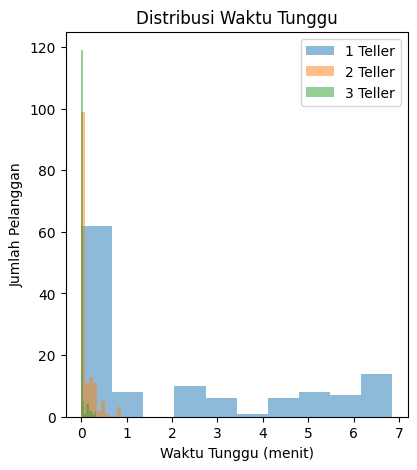

In [16]:
plt.figure(figsize=(15, 5))

# Plot 1: Distribusi waktu tunggu untuk berbagai jumlah teller (Tugas 1)
plt.subplot(1, 3, 1)
for num_tellers in NUM_TELLERS_LIST:
    plt.hist(wait_times_dict[num_tellers], bins=10, alpha=0.5, label=f"{num_tellers} Teller")
plt.xlabel("Waktu Tunggu (menit)")
plt.ylabel("Jumlah Pelanggan")
plt.title("Distribusi Waktu Tunggu")
plt.legend()

Text(0.5, 1.0, 'Utilisasi Teller Sepanjang Waktu')

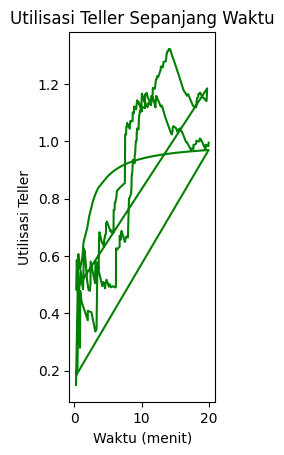

In [17]:
# Plot 2: Utilisasi teller sepanjang waktu (Tugas 3)
plt.subplot(1, 3, 2)
plt.plot(utilization_times, utilization_values, color="green")
plt.xlabel("Waktu (menit)")
plt.ylabel("Utilisasi Teller")
plt.title("Utilisasi Teller Sepanjang Waktu")

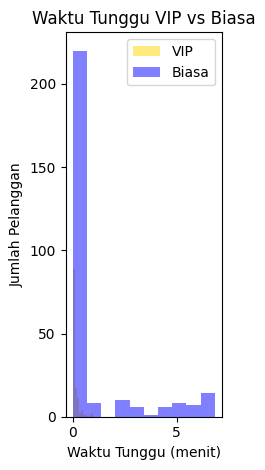

In [18]:
# Plot 3: Perbandingan waktu tunggu VIP vs pelanggan biasa (Tugas 4)
plt.subplot(1, 3, 3)
plt.hist(vip_wait_times, bins=10, alpha=0.5, label="VIP", color="gold")
plt.hist(regular_wait_times, bins=10, alpha=0.5, label="Biasa", color="blue")
plt.xlabel("Waktu Tunggu (menit)")
plt.ylabel("Jumlah Pelanggan")
plt.title("Waktu Tunggu VIP vs Biasa")
plt.legend()

plt.tight_layout()
plt.show()